In [1]:
from keras.layers import Conv2D, UpSampling2D, InputLayer, Conv2DTranspose
from keras.layers import Activation, Dense, Dropout, Flatten
from keras.layers import BatchNormalization
from keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img
from skimage.color import rgb2lab, lab2rgb, rgb2gray, xyz2lab
from skimage.io import imsave
import numpy as np
import os
import random
import tensorflow as tf

C:\Users\ruthw_8xj55dr\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


In [7]:
import cv2
import numpy as np
import tkinter as tk
from tkinter import Button, filedialog
from tensorflow.keras.preprocessing.image import img_to_array
from skimage.color import rgb2lab
from PIL import Image, ImageTk

# Initialize global variables for captured image, X, and Y
captured_image = None
X = None
Y = None

# Function to capture the current frame from the camera
def capture_image():
    global captured_image, X, Y
    ret, frame = cap.read()
    if ret:
        # Resize to square and then to 400x400
        height, width = frame.shape[:2]
        min_side = min(height, width)
        start_x = (width - min_side) // 2
        start_y = (height - min_side) // 2
        cropped_frame = frame[start_y:start_y + min_side, start_x:start_x + min_side]
        captured_image = cv2.resize(cropped_frame, (400, 400))
        
        # Convert the image from BGR to RGB
        process_image(cv2.cvtColor(captured_image, cv2.COLOR_BGR2RGB))

        print("Image captured and processed!")

        # Close the window after capturing the image
        cap.release()
        cv2.destroyAllWindows()

# Function to process an image
def process_image(image_rgb):
    global X, Y
    # Convert the image to a NumPy array of floats
    image = img_to_array(image_rgb)
    image = np.array(image, dtype=float)

    # RGB to LAB conversion
    X = rgb2lab(1.0 / 255 * image)[:, :, 0]  # L channel
    Y = rgb2lab(1.0 / 255 * image)[:, :, 1:]  # a and b channels
    Y /= 128  # Normalize the a and b channels

    # Reshaping to the required shape (1, 400, 400, 1) for X and (1, 400, 400, 2) for Y
    X = X.reshape(1, 400, 400, 1)
    Y = Y.reshape(1, 400, 400, 2)

# Function to browse and select an image file
def browse_image():
    global captured_image
    file_path = filedialog.askopenfilename(filetypes=[("Image files", "*.png")])
    if file_path:
        # Open the image using PIL
        image = Image.open(file_path).convert("RGB")
        
        # Crop the image to a square by taking the center
        width, height = image.size
        min_side = min(width, height)
        left = (width - min_side) // 2
        top = (height - min_side) // 2
        right = left + min_side
        bottom = top + min_side
        cropped_image = image.crop((left, top, right, bottom))
        
        # Resize the cropped square to 400x400
        cropped_image = cropped_image.resize((400, 400))
        captured_image = np.array(cropped_image)
        
        # Process the image
        process_image(captured_image)
        print("Image selected, cropped, and processed!")

# Function to update the camera feed in the Tkinter window
def update_frame():
    ret, frame = cap.read()
    if ret:
        # Convert the frame to RGB for Tkinter
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        # Convert the image to PIL format
        img = Image.fromarray(frame_rgb)
        # Resize the image to fit the window (700x400)
        img = img.resize((700, 400))
        # Convert to ImageTk format
        img_tk = ImageTk.PhotoImage(image=img)
        
        # Update the image on the Tkinter canvas
        canvas.create_image(0, 0, anchor="nw", image=img_tk)
        canvas.img_tk = img_tk  # Keep a reference to the image

    # Schedule the next update in 5 ms
    root.after(5, update_frame)

# Initialize the camera (camera index 0 is typically the default webcam)
cap = cv2.VideoCapture(0)

# Create a Tkinter window
root = tk.Tk()
root.title("Camera Capture")

# Create a canvas to display the camera feed
canvas = tk.Canvas(root, width=700, height=400)
canvas.pack()

# Create the capture button
capture_button = Button(root, text="Capture", command=capture_image)
capture_button.pack(padx=5, pady=8, side="left")

# Create the browse button
browse_button = Button(root, text="Browse", command=browse_image)
browse_button.pack(padx=5, pady=8, side="left")

# Start the camera feed update loop
update_frame()

# Start the Tkinter GUI loop
root.mainloop()

# Release the camera and close the OpenCV window after the Tkinter window is closed
cap.release()
cv2.destroyAllWindows()

Image captured and processed!


In [8]:
# Building the neural network
model = Sequential()
model.add(InputLayer(input_shape=(None, None, 1)))
model.add(Conv2D(8, (3, 3), activation='relu', padding='same', strides=2))
model.add(Conv2D(8, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(16, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(16, (3, 3), activation='relu', padding='same', strides=2))
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(32, (3, 3), activation='relu', padding='same', strides=2))
model.add(UpSampling2D((2, 2)))
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(UpSampling2D((2, 2)))
model.add(Conv2D(16, (3, 3), activation='relu', padding='same'))
model.add(UpSampling2D((2, 2)))
model.add(Conv2D(2, (3, 3), activation='tanh', padding='same'))

C:\Users\ruthw_8xj55dr\anaconda3\Lib\site-packages\keras\src\layers\core\input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [9]:
# Finish model
model.compile(optimizer='rmsprop',loss='mse')

In [10]:
model.fit(x=X, 
    y=Y,
    batch_size=1,
    epochs=1000)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0429
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0868
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0112
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0053
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0049
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0048
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0045
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0043
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0042
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0041
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0041
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0041
Epoch 13/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0041
Epoch 14/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0039
Epoch 15/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0037
Epoch 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0011
Epoch 83/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0011
Epoch 84/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0010
Epoch 85/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0015
Epoch 86/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0018
Epoch 87/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0041
Epoch 88/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0020
Epoch 89/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0012
Epoch 90/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0010
Epoch 91/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 9.3847e-04
Epoch 92/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 8.9161e-04
Epoch 93/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 8.3865e-04
Epoch 94/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 8.5481e-04
Epoch 95/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 8.6829e-04
Epoch 96/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - lo

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 4.6368e-04
Epoch 161/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 4.5292e-04
Epoch 162/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 4.4468e-04
Epoch 163/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 4.3870e-04
Epoch 164/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 4.3487e-04
Epoch 165/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 4.3491e-04
Epoch 166/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 4.4121e-04
Epoch 167/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 4.7264e-04
Epoch 168/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 5.7149e-04
Epoch 169/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0015
Epoch 170/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0059
Epoch 171/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0018
Epoch 172/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 5.8215e-04
Epoch 173/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 5.3410e-04
Epoch 174/1000
1/1 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 3.5351e-04
Epoch 238/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 3.5203e-04
Epoch 239/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 3.5062e-04
Epoch 240/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 3.4924e-04
Epoch 241/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 3.4793e-04
Epoch 242/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 3.4678e-04
Epoch 243/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 3.4632e-04
Epoch 244/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 3.4996e-04
Epoch 245/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 3.8010e-04
Epoch 246/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 7.2988e-04
Epoch 247/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0045
Epoch 248/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 4.7177e-04
Epoch 249/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 4.2028e-04
Epoch 250/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 3.9263e-04
Epoch 251/1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 3.3070e-04
Epoch 315/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 3.2793e-04
Epoch 316/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 3.2555e-04
Epoch 317/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 3.2345e-04
Epoch 318/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 3.2155e-04
Epoch 319/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 3.1985e-04
Epoch 320/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 3.1832e-04
Epoch 321/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 3.1690e-04
Epoch 322/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 3.1559e-04
Epoch 323/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 3.1440e-04
Epoch 324/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 3.1330e-04
Epoch 325/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 3.1229e-04
Epoch 326/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 3.1133e-04
Epoch 327/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 3.1044e-04
Epoch 3

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 2.6007e-04
Epoch 623/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 2.5965e-04
Epoch 624/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 2.5922e-04
Epoch 625/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 2.5880e-04
Epoch 626/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 2.5840e-04
Epoch 627/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 2.5802e-04
Epoch 628/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 2.5772e-04
Epoch 629/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 2.5756e-04
Epoch 630/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 2.5795e-04
Epoch 631/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 2.6023e-04
Epoch 632/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 2.7145e-04
Epoch 633/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 3.1529e-04
Epoch 634/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 5.7508e-04
Epoch 635/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0013
Epoch 636/1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 2.4754e-04
Epoch 700/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 2.4947e-04
Epoch 701/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 2.5812e-04
Epoch 702/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 2.9677e-04
Epoch 703/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 3.9206e-04
Epoch 704/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 8.3247e-04
Epoch 705/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0018
Epoch 706/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 3.8486e-04
Epoch 707/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 2.7147e-04
Epoch 708/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 2.5798e-04
Epoch 709/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 2.5335e-04
Epoch 710/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 2.5083e-04
Epoch 711/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 2.4919e-04
Epoch 712/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 2.4808e-04
Epoch 713/1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 2.3717e-04
Epoch 777/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 2.3674e-04
Epoch 778/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 2.3635e-04
Epoch 779/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 2.3602e-04
Epoch 780/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 2.3573e-04
Epoch 781/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 2.3544e-04
Epoch 782/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 2.3516e-04
Epoch 783/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 2.3493e-04
Epoch 784/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 2.3476e-04
Epoch 785/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 2.3473e-04
Epoch 786/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 2.3510e-04
Epoch 787/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 2.3685e-04
Epoch 788/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 2.4252e-04
Epoch 789/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 2.6583e-04
Epoch 7

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0022
Epoch 854/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 7.7501e-04
Epoch 855/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 2.8356e-04
Epoch 856/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 2.6361e-04
Epoch 857/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 2.5484e-04
Epoch 858/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 2.4890e-04
Epoch 859/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 2.4521e-04
Epoch 860/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 2.4244e-04
Epoch 861/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 2.3996e-04
Epoch 862/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 2.3795e-04
Epoch 863/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 2.3637e-04
Epoch 864/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 2.3516e-04
Epoch 865/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 2.3422e-04
Epoch 866/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 2.3344e-04
Epoch 867/1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 2.3281e-04
Epoch 931/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 2.3077e-04
Epoch 932/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 2.2925e-04
Epoch 933/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 2.2808e-04
Epoch 934/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 2.2710e-04
Epoch 935/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 2.2629e-04
Epoch 936/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 2.2557e-04
Epoch 937/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 2.2502e-04
Epoch 938/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 2.2453e-04
Epoch 939/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 2.2403e-04
Epoch 940/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 2.2358e-04
Epoch 941/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 2.2315e-04
Epoch 942/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 2.2277e-04
Epoch 943/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 2.2242e-04
Epoch 9

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


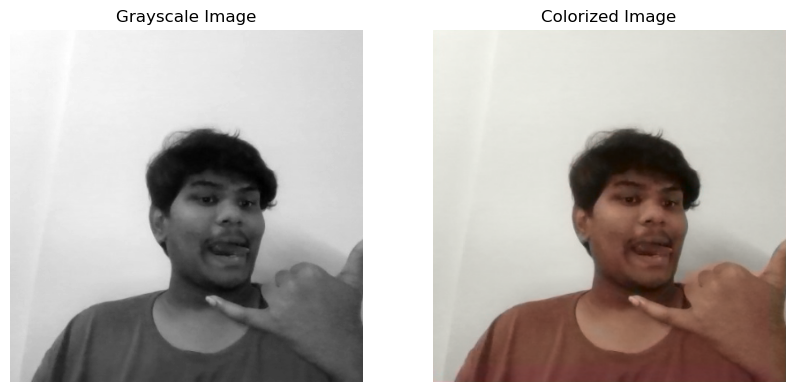

In [11]:
import matplotlib.pyplot as plt

output = model.predict(X)
output *= 128  # Scale the output as per LAB color space requirements

# Convert output to image format and save
from skimage import img_as_ubyte

# Output colorizations
cur = np.zeros((400, 400, 3))
cur[:, :, 0] = X[0][:, :, 0]  # Lightness channel from the input
cur[:, :, 1:] = output[0]     # Predicted color channels

# Convert to uint8 before saving
cur_uint8 = img_as_ubyte(lab2rgb(cur))
imsave("img_result.png", cur_uint8)

# Convert grayscale version to uint8 and save
gray_version = img_as_ubyte(rgb2gray(lab2rgb(cur)))
imsave("img_gray_version.png", gray_version)

# Display both images using matplotlib
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Load the saved images for display
colorized_image = plt.imread("img_result.png")
grayscale_image = plt.imread("img_gray_version.png")



# Display grayscale image
axes[0].imshow(grayscale_image, cmap="gray")
axes[0].set_title("Grayscale Image")
axes[0].axis('off')  # Hide axes for better display

# Display colorized image
axes[1].imshow(colorized_image)
axes[1].set_title("Colorized Image")
axes[1].axis('off')  # Hide axes for better display

# Show the plot
plt.show()